## Netflix Movie Data Analysis Project


Netflix is know for it's work in data science , AI and ML, particularly for building string recommendation models and algorithms that understand custom behaviour and patterns. Suppose you are working in a data-driven job role, and you have a dataset of more than 9k movies..

In [98]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [99]:
df = pd.read_excel("netflixcsv.xlsx")

In [100]:
df.head(5)

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940.0,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151.0,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122.0,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076.0,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793.0,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [101]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Release_Date       9827 non-null   datetime64[ns]
 1   Title              9827 non-null   object        
 2   Overview           9827 non-null   object        
 3   Popularity         9826 non-null   float64       
 4   Vote_Count         9826 non-null   float64       
 5   Vote_Average       9826 non-null   float64       
 6   Original_Language  9826 non-null   object        
 7   Genre              9826 non-null   object        
 8   Poster_Url         9826 non-null   object        
dtypes: datetime64[ns](1), float64(3), object(5)
memory usage: 691.8+ KB


## Data Cleaning
1. here it is visible that Release_Date is in object Dtype

In [102]:
df['Genre'].head(10)

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
5               Action, Crime, Thriller
6             Horror, Mystery, Thriller
7                              Thriller
8                Action, Crime, Fantasy
9                       Science Fiction
Name: Genre, dtype: object

In [103]:
df.duplicated().sum()

np.int64(9)

In [104]:
df.describe()

,Release_Date,Popularity,Vote_Count,Vote_Average
count,9827,9826.000000,9826.000000,9826.000000
mean,2006-09-23 11:05:51.317797888,40.323951,1392.943721,6.439467
min,1902-04-17 00:00:00,13.354000,0.000000,0.000000
25%,2000-10-18 00:00:00,16.128250,146.000000,5.900000
50%,2011-09-13 00:00:00,21.195000,444.000000,6.500000
75%,2017-11-22 00:00:00,35.179250,1376.000000,7.100000
max,2024-07-03 00:00:00,5083.954000,31077.000000,10.000000
std,NaN,108.879332,2611.303856,1.129797


In [105]:
df["Vote_Average"].unique()

array([ 8.3,  8.1,  6.3,  7.7,  7. ,  6.6,  6.8,  5.3,  7.2,  5.9,  7.3,
        7.1,  5.1,  4.6,  6. ,  8.2,  5.4,  6.1,  8.4,  6.9,  5.8,  7.4,
        7.8,  8. ,  6.2,  6.7,  7.6,  8.6,  4.8,  5.5,  7.9,  6.4,  7.5,
        5.7,  2.2,  6.5,  0. ,  5.6,  5.2,  5. ,  8.5,  3.5,  4. ,  3.3,
        4.7,  4.2,  4.3,  2. ,  4.1,  4.9,  8.7,  4.5,  9.1,  4.4,  3.6,
        nan,  2.8,  3.9,  3.8,  9. ,  3. ,  3.1,  3.7,  3.4,  8.9,  2.9,
        8.8,  3.2,  1.5,  9.2,  2.5,  1.8,  2.4,  2.6, 10. ])

In [106]:
df["Vote_Count"].unique()

array([8940., 1151.,  122., ..., 2395.,  960., 1319.], shape=(3267,))

In [107]:
df["Vote_Count"]=df["Vote_Count"].astype(float)
df["Vote_Average"]=df["Vote_Average"].astype(float)

In [108]:
df['Release_Date']=pd.to_datetime(df['Release_Date'])
print(df['Release_Date'])

0      2021-12-15
1      2022-03-01
2      2022-02-25
3      2021-11-24
4      2021-12-22
          ...    
9832   1973-10-15
9833   2020-10-01
9834   2016-05-06
9835   2021-03-31
9836   1984-09-23
Name: Release_Date, Length: 9837, dtype: datetime64[ns]


In [109]:
df['Release_Date']=df['Release_Date'].dt.year
df['Release_Date'].dtypes

dtype('float64')

In [110]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021.0,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940.0,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022.0,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151.0,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022.0,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122.0,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021.0,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076.0,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021.0,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793.0,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [111]:
##Dropping the columns which are not required for analysis
cols = ['Overview','Poster_Url','Original_Language']

In [112]:
df.drop(cols,axis=1,inplace=True)


In [113]:
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='object')

**Categorizing `Vote_Average` Column** 
We would cut the `Vote_Average` values and make 4 categories `popular` `average` `below_average` `not_popular` to describe it more using `categorize_col` function

In [114]:
def categorize_col(df,col,labels):
    edges = [df[col].describe()['min'],
             df[col].describe()['25%'],
             df[col].describe()['50%'],
             df[col].describe()['75%'],
             df[col].describe()['max']]
    df[col] = pd.cut(df[col],edges,labels=labels,duplicates='drop')
    return df


In [115]:
labels = ['not_popular','below_avg','average','popular']
categorize_col(df,'Vote_Average', labels)


,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940.0,popular,"Action, Adventure, Science Fiction"
1,2022.0,The Batman,3827.658,1151.0,popular,"Crime, Mystery, Thriller"
2,2022.0,No Exit,2618.087,122.0,below_avg,Thriller
3,2021.0,Encanto,2402.201,5076.0,popular,"Animation, Comedy, Family, Fantasy"
4,2021.0,The King's Man,1895.511,1793.0,average,"Action, Adventure, Thriller, War"
...,...,...,...,...,...,...
9832,1973.0,Badlands,13.357,896.0,popular,"Drama, Crime"
9833,2020.0,Violent Delights,13.356,8.0,not_popular,Horror
9834,2016.0,The Offering,13.355,94.0,not_popular,"Mystery, Thriller, Horror"
9835,2021.0,The United States vs. Billie Holiday,13.354,152.0,average,"Music, Drama, History"


In [116]:
df['Vote_Average'].unique()

['popular', 'below_avg', 'average', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'below_avg' < 'average' < 'popular']

In [117]:
df['Vote_Average'].value_counts()

Vote_Average
not_popular    2467
popular        2450
average        2411
below_avg      2398
Name: count, dtype: int64

## We had split genres into a list and then explode our dataframe to have only one genre per row for each movie

In [118]:
df["Genre"].head(10)

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
5               Action, Crime, Thriller
6             Horror, Mystery, Thriller
7                              Thriller
8                Action, Crime, Fantasy
9                       Science Fiction
Name: Genre, dtype: object

In [119]:
df['Genre']=df['Genre'].str.split(', ')

In [120]:
df = df.explode("Genre").reset_index(drop=True)

In [121]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940.0,popular,Action
1,2021.0,Spider-Man: No Way Home,5083.954,8940.0,popular,Adventure
2,2021.0,Spider-Man: No Way Home,5083.954,8940.0,popular,Science Fiction
3,2022.0,The Batman,3827.658,1151.0,popular,Crime
4,2022.0,The Batman,3827.658,1151.0,popular,Mystery


In [122]:
df['Genre']=df['Genre'].astype('category')
df['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25803 entries, 0 to 25802
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25793 non-null  float64 
 1   Title         25793 non-null  object  
 2   Popularity    25792 non-null  float64 
 3   Vote_Count    25792 non-null  float64 
 4   Vote_Average  25551 non-null  category
 5   Genre         25792 non-null  category
dtypes: category(2), float64(3), object(1)
memory usage: 857.8+ KB


## Now Let us answer few Data Visualization Questions

In [124]:
sns.set_style('whitegrid')

## What is the most frequent genre of movies released on Netflix ?

In [125]:
sns.set_style('whitegrid')

In [126]:
df['Genre'].describe()

count     25792
unique       19
top       Drama
freq       3744
Name: Genre, dtype: object

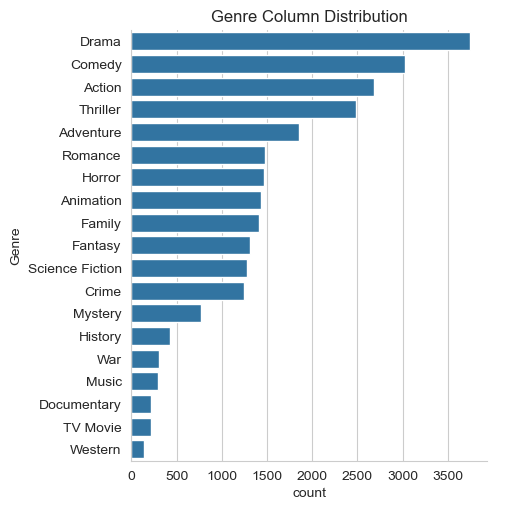

In [128]:
sns.catplot(y='Genre', data = df, kind='count', order=df['Genre'].value_counts().index)
plt.title("Genre Column Distribution")
plt.show()

**In this question we observed Drama genre is the most frequent genre in our dataset and has appeared more than other 18 genres.**

## What genres has highest votes ?

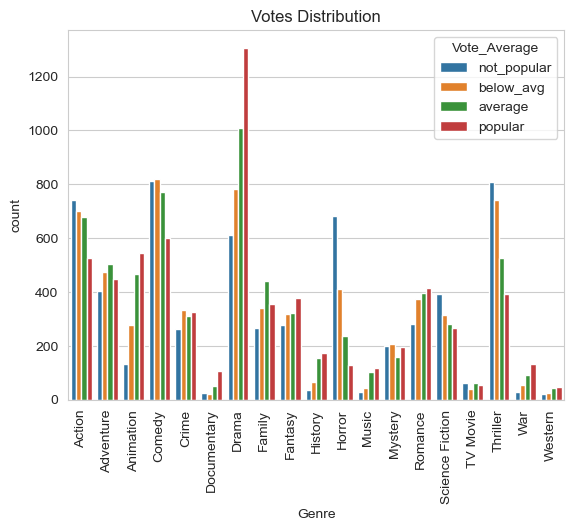

In [140]:
sns.countplot(x='Genre',hue="Vote_Average", data=df)
plt.xticks(rotation=90)
plt.title('Votes Distribution')
plt.show()

**Drama Genre has the highest vote in our datasets**

## What movie got the highest popularity ? What is its genre ?

In [136]:
df[df['Popularity']==df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940.0,popular,Action
1,2021.0,Spider-Man: No Way Home,5083.954,8940.0,popular,Adventure
2,2021.0,Spider-Man: No Way Home,5083.954,8940.0,popular,Science Fiction


**Spider-Man: No Way Home has the highest popularity rate in our dataset and it has genres of action, adventure and science fiction**

## What movie got the lowest popularity ? What is its genre ?

In [137]:
df[df['Popularity']==df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25797,2021.0,The United States vs. Billie Holiday,13.354,152.0,average,Music
25798,2021.0,The United States vs. Billie Holiday,13.354,152.0,average,Drama
25799,2021.0,The United States vs. Billie Holiday,13.354,152.0,average,History
25800,1984.0,Threads,13.354,186.0,popular,War
25801,1984.0,Threads,13.354,186.0,popular,Drama
25802,1984.0,Threads,13.354,186.0,popular,Science Fiction


**The Unites States vs Billie Holliday and Threads has the lowest rate in our dataset and it has genres of music, drama, war, sci-fi and history**

## Which year has the most filmmed movies ?

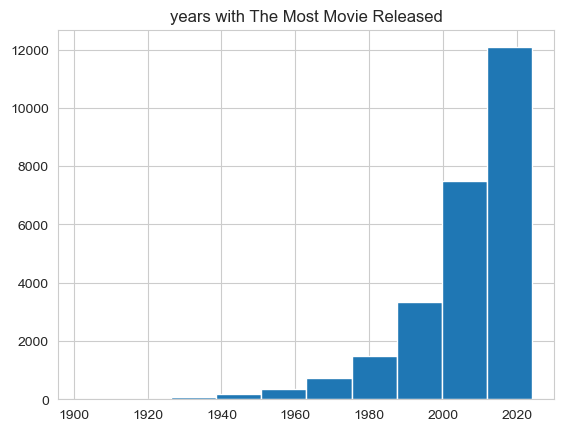

In [138]:
df['Release_Date'].hist()
plt.title("years with The Most Movie Released")
plt.show()

**Year 2020 has the highest filming rate in our dataset**